In [1]:
import pandas as pd
import numpy as np
import h5py
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from tqdm import tqdm
import matplotlib.pyplot as plt
import time
import warnings
import pickle
from datetime import datetime
import json
warnings.filterwarnings('ignore')

# Use GPU 1 (second GPU) - GPU 0 is used by other script
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():    
    print(f"GPU Memory: {torch.cuda.get_device_properties(1).total_memory / 1e9:.1f} GB")
    print(f"GPU Name: {torch.cuda.get_device_name(1)}\n")


Using device: cuda:1
GPU Memory: 47.7 GB
GPU Name: NVIDIA L40S



## 1. Metadata Preprocessing (Same as baseline)

In [2]:
# Load metadata
data_dir = Path('data')
train_meta = pd.read_csv(data_dir / 'new-train-metadata.csv', low_memory=False)
test_meta = pd.read_csv(data_dir / 'students-test-metadata.csv', low_memory=False)

print("Metadata loaded:")
print(f"  Train: {len(train_meta):,} samples")
print(f"  Test: {len(test_meta):,} samples\n")

Metadata loaded:
  Train: 400,959 samples
  Test: 100 samples



In [3]:
# Define features (same as baseline)
NUMERICAL_FEATURES = [
    'tbp_lv_H', 'tbp_lv_areaMM2', 'tbp_lv_minorAxisMM',
    'tbp_lv_perimeterMM', 'tbp_lv_deltaB', 'tbp_lv_Hext',
    'clin_size_long_diam_mm', 'tbp_lv_radial_color_std_max',
    'tbp_lv_B', 'tbp_lv_color_std_mean', 'tbp_lv_Aext',
    'tbp_lv_stdLExt', 'tbp_lv_norm_color', 'tbp_lv_A',
    'age_approx'
]

CATEGORICAL_FEATURES = [
    'sex', 'anatom_site_general', 'tbp_tile_type', 'tbp_lv_location_simple'
]

In [4]:
def preprocess_metadata(df, is_train=True, scaler=None, encoders=None):
    df = df.copy()
    
    for col in NUMERICAL_FEATURES:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median() if is_train else 0)
    
    for col in CATEGORICAL_FEATURES:
        if col in df.columns:
            df[col] = df[col].fillna('missing')
    
    if is_train:
        scaler = StandardScaler()
        df[NUMERICAL_FEATURES] = scaler.fit_transform(df[NUMERICAL_FEATURES])
    else:
        df[NUMERICAL_FEATURES] = scaler.transform(df[NUMERICAL_FEATURES])
    
    if is_train:
        encoders = {}
        encoded_dfs = []
        for col in CATEGORICAL_FEATURES:
            encoded = pd.get_dummies(df[col], prefix=col, dtype=float)
            encoders[col] = encoded.columns.tolist()
            encoded_dfs.append(encoded)
        result_df = pd.concat([df[NUMERICAL_FEATURES]] + encoded_dfs, axis=1)
    else:
        encoded_dfs = []
        for col in CATEGORICAL_FEATURES:
            encoded = pd.get_dummies(df[col], prefix=col, dtype=float)
            for train_col in encoders[col]:
                if train_col not in encoded.columns:
                    encoded[train_col] = 0
            encoded = encoded[encoders[col]]
            encoded_dfs.append(encoded)
        result_df = pd.concat([df[NUMERICAL_FEATURES]] + encoded_dfs, axis=1)
    
    return result_df, scaler, encoders

train_meta_processed, scaler, encoders = preprocess_metadata(train_meta, is_train=True)
test_meta_processed, _, _ = preprocess_metadata(test_meta, is_train=False, scaler=scaler, encoders=encoders)

train_meta_processed['isic_id'] = train_meta['isic_id'].values
train_meta_processed['target'] = train_meta['target'].values
test_meta_processed['isic_id'] = test_meta['isic_id'].values

metadata_dim = len(train_meta_processed.columns) - 2
print(f"Metadata dimension: {metadata_dim}\n")

Metadata dimension: 34



## 2. Hybrid Dataset (Same as baseline)

In [5]:
class HybridDataset(Dataset):
    def __init__(self, hdf5_path, metadata_df, transform=None, is_test=False):
        self.hdf5_path = hdf5_path
        self.transform = transform
        self.is_test = is_test
        self.hdf5_file = None
        
        with h5py.File(hdf5_path, 'r') as f:
            available_ids = set(f.keys())
        
        self.metadata = metadata_df[
            metadata_df['isic_id'].isin(available_ids)
        ].reset_index(drop=True)
        
        feature_cols = [col for col in self.metadata.columns 
                       if col not in ['isic_id', 'target']]
        self.metadata_features = self.metadata[feature_cols].values.astype(np.float32)
        
        print(f"✓ {len(self.metadata)} samples from {Path(hdf5_path).name}")
        
        if not is_test and 'target' in self.metadata.columns:
            print(f"  Distribution: {self.metadata['target'].value_counts().to_dict()}")
    
    def _ensure_hdf5_open(self):
        if self.hdf5_file is None:
            self.hdf5_file = h5py.File(self.hdf5_path, 'r', swmr=True)
    
    def __len__(self):
        return len(self.metadata)
    
    def __getitem__(self, idx):
        self._ensure_hdf5_open()
        
        row = self.metadata.iloc[idx]
        image_id = row['isic_id']
        
        img_array = self.hdf5_file[image_id][:]
        image = Image.fromarray(img_array)
        
        if self.transform:
            image = self.transform(image)
        
        metadata = torch.tensor(self.metadata_features[idx], dtype=torch.float32)
        
        if self.is_test:
            return image, metadata, image_id
        else:
            label = row['target']
            return image, metadata, label

In [6]:
# Transforms
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Split
train_df, val_df = train_test_split(
    train_meta_processed, test_size=0.2, random_state=42,
    stratify=train_meta_processed['target']
)

print(f"Split: {len(train_df):,} train / {len(val_df):,} val\n")

# Create datasets
train_dataset = HybridDataset(
    hdf5_path=data_dir / 'train-image-preprocessed.hdf5',
    metadata_df=train_df, transform=train_transform, is_test=False
)

val_dataset = HybridDataset(
    hdf5_path=data_dir / 'train-image-preprocessed.hdf5',
    metadata_df=val_df, transform=val_transform, is_test=False
)

test_dataset = HybridDataset(
    hdf5_path=data_dir / 'test-image-preprocessed.hdf5',
    metadata_df=test_meta_processed, transform=val_transform, is_test=True
)

# DataLoaders
BATCH_SIZE = 256
NUM_WORKERS = 16

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True
)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True
)

test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True
)

print(f"DataLoaders: {BATCH_SIZE} batch, {NUM_WORKERS} workers")
print(f"Batches: {len(train_loader)} train, {len(val_loader)} val\n")

Split: 320,767 train / 80,192 val

✓ 320767 samples from train-image-preprocessed.hdf5
  Distribution: {0: 320493, 1: 274}
✓ 80192 samples from train-image-preprocessed.hdf5
  Distribution: {0: 80123, 1: 69}
✓ 100 samples from test-image-preprocessed.hdf5
DataLoaders: 256 batch, 16 workers
Batches: 1253 train, 314 val



## 3. Focal Loss (Same as baseline)

In [7]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        p_t = torch.exp(-bce_loss)
        focal_term = (1 - p_t) ** self.gamma
        focal_loss = self.alpha * focal_term * bce_loss
        return focal_loss.mean()

## 4. ResNet34 Hybrid Model ⭐ NEW!

In [8]:
class MetadataProcessor(nn.Module):
    """Same metadata processor as baseline"""
    def __init__(self, input_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
    
    def forward(self, x):
        return self.fc(x)


class ResNet34Hybrid(nn.Module):
    """
    Hybrid model with ResNet34 backbone
    
    Architecture:
      - ResNet34 (pretrained) → 512 features
      - Metadata MLP → 64 features
      - Concatenate → 576 features
      - Classifier → 1 output
    """
    def __init__(self, metadata_dim):
        super().__init__()
        
        # Load pretrained ResNet34
        self.resnet = models.resnet34(pretrained=True)
        
        # Remove original classifier
        num_features = self.resnet.fc.in_features  # 512
        self.resnet.fc = nn.Identity()
        
        # Freeze early layers (optional)
        # Freeze first 3 layers (conv1, bn1, layer1, layer2)
        for name, param in self.resnet.named_parameters():
            if 'layer3' not in name and 'layer4' not in name:
                param.requires_grad = False
        
        # Metadata processor
        self.metadata_processor = MetadataProcessor(metadata_dim)
        
        # Combined classifier
        # ResNet34 outputs 512 features
        self.classifier = nn.Sequential(
            nn.Linear(512 + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )
    
    def forward(self, image, metadata):
        # Extract image features
        img_features = self.resnet(image)
        
        # Process metadata
        meta_features = self.metadata_processor(metadata)
        
        # Combine and classify
        combined = torch.cat([img_features, meta_features], dim=1)
        output = self.classifier(combined)
        return output


# Create model
model = ResNet34Hybrid(metadata_dim=metadata_dim).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("="*70)
print("RESNET34 HYBRID MODEL")
print("="*70)
print(f"Backbone: ResNet34 (ImageNet pretrained)")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")
print(f"Image features: 512 (from ResNet34)")
print(f"Metadata features: 64 (from MLP)")
print(f"Combined: 576 → Classifier → 1 output")
print("="*70 + "\n")

RESNET34 HYBRID MODEL
Backbone: ResNet34 (ImageNet pretrained)
Total parameters: 21,478,145
Trainable parameters: 20,130,241
Frozen parameters: 1,347,904
Image features: 512 (from ResNet34)
Metadata features: 64 (from MLP)
Combined: 576 → Classifier → 1 output



## 5. Training Setup (Same as baseline)

In [9]:
criterion = FocalLoss(alpha=0.25, gamma=2.0)
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=5, factor=0.5
)

print("Training setup:")
print(f"  Loss: Focal Loss (alpha=0.25, gamma=2.0)")
print(f"  Optimizer: Adam (lr=0.0005, weight_decay=1e-5)")
print(f"  Scheduler: ReduceLROnPlateau (patience=5)\n")

Training setup:
  Loss: Focal Loss (alpha=0.25, gamma=2.0)
  Optimizer: Adam (lr=0.0005, weight_decay=1e-5)
  Scheduler: ReduceLROnPlateau (patience=5)



## 6. Training Functions (Same as baseline)

In [11]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    start_time = time.time()
    
    for images, metadata, labels in tqdm(loader, desc="Training", ncols=100):
        images = images.to(device, non_blocking=True)
        metadata = metadata.to(device, non_blocking=True)
        labels = labels.float().unsqueeze(1).to(device, non_blocking=True)
        
        optimizer.zero_grad()
        outputs = model(images, metadata)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        all_preds.extend(torch.sigmoid(outputs).detach().cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    elapsed = time.time() - start_time
    epoch_loss = running_loss / len(loader)
    epoch_auc = roc_auc_score(all_labels, all_preds)
    
    return epoch_loss, epoch_auc, elapsed


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, metadata, labels in tqdm(loader, desc="Validation", ncols=100):
            images = images.to(device, non_blocking=True)
            metadata = metadata.to(device, non_blocking=True)
            labels = labels.float().unsqueeze(1).to(device, non_blocking=True)
            
            outputs = model(images, metadata)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            all_preds.extend(torch.sigmoid(outputs).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(loader)
    epoch_auc = roc_auc_score(all_labels, all_preds)
    
    return epoch_loss, epoch_auc, all_preds, all_labels

## 7. Training Loop

In [ ]:
NUM_EPOCHS = 25
best_auc = 0.0
history = {
    'train_loss': [], 'train_auc': [], 'train_time': [],
    'val_loss': [], 'val_auc': []
}

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
results_dir = Path('results') / f'resnet34_hybrid_{timestamp}'
results_dir.mkdir(parents=True, exist_ok=True)

print("="*70)
print("STARTING TRAINING - RESNET34 HYBRID")
print("="*70)
print(f"Results: {results_dir}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Expected improvement: 0.927 → 0.95-0.96")
print("="*70 + "\n")

total_start = time.time()

for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*70}")
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"{'='*70}")
    
    train_loss, train_auc, train_time = train_epoch(
        model, train_loader, criterion, optimizer, device
    )
    
    val_loss, val_auc, val_preds, val_labels = validate(
        model, val_loader, criterion, device
    )
    
    history['train_loss'].append(train_loss)
    history['train_auc'].append(train_auc)
    history['train_time'].append(train_time)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)
    
    print(f"\nResults:")
    print(f"  Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.4f} | Time: {train_time:.1f}s")
    print(f"  Val Loss:   {val_loss:.4f} | Val AUC:   {val_auc:.4f}")
    
    if val_auc > best_auc:
        best_auc = val_auc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_auc': val_auc,
        }, results_dir / 'best_resnet34_hybrid.pth')
        print(f"  ✓ Saved best model (AUC: {best_auc:.4f})")
    
    scheduler.step(val_auc)
    print(f"  Learning rate: {optimizer.param_groups[0]['lr']:.6f}")
    
    if optimizer.param_groups[0]['lr'] < 1e-6:
        print(f"\n  LR too small, stopping...")
        break

total_time = time.time() - total_start

# Save results
with open(results_dir / 'training_results.pkl', 'wb') as f:
    pickle.dump({
        'timestamp': timestamp,
        'model': 'ResNet34 Hybrid',
        'best_auc': best_auc,
        'history': history,
        'total_time': total_time,
        'batch_size': BATCH_SIZE,
        'metadata_dim': metadata_dim,
        'total_params': total_params,
        'trainable_params': trainable_params,
    }, f)

with open(results_dir / 'preprocessors.pkl', 'wb') as f:
    pickle.dump({'scaler': scaler, 'encoders': encoders}, f)

print(f"\n{'='*70}")
print("TRAINING COMPLETE")
print(f"{'='*70}")
print(f"Total time: {total_time/60:.1f} minutes")
print(f"Best validation AUC: {best_auc:.4f}")
print(f"Improvement vs baseline: {best_auc - 0.9365:.4f}")
print(f"Improvement vs simple CNN: {best_auc - 0.51:.4f}")
print(f"\n✓ Results saved to: {results_dir}")
print(f"{'='*70}\n")

## 8. Evaluation & Predictions

## 8A. Load Previous Run (Optional)
You can set `load_results_dir` to a results directory (e.g., `'results/resnet34_hybrid_20251107_182054'`) to reload a previous run and redo evaluation/prediction. If `None`, the notebook will use the current run.

Loading previous run from: results/resnet34_hybrid_20251107_182054


Validation: 100%|█████████████████████████████████████████████████| 314/314 [00:24<00:00, 12.86it/s]



✓ ROC curve saved



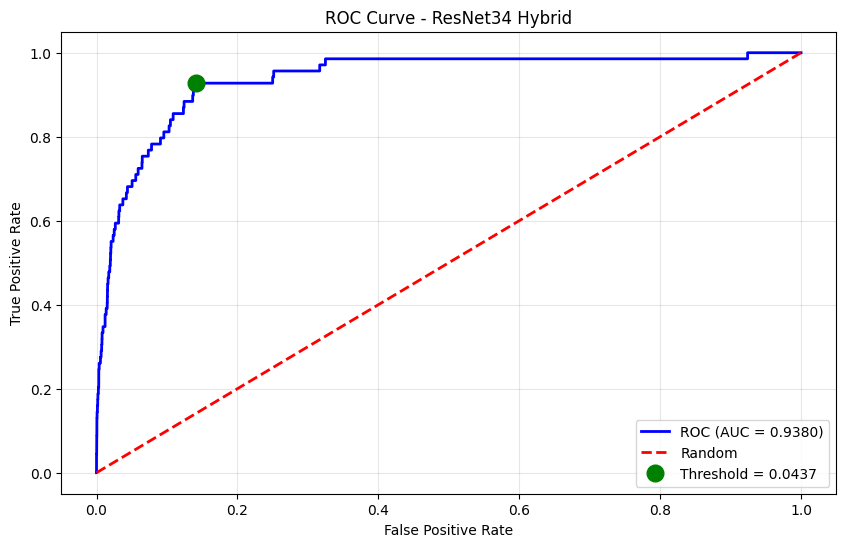

✓ Training plots saved



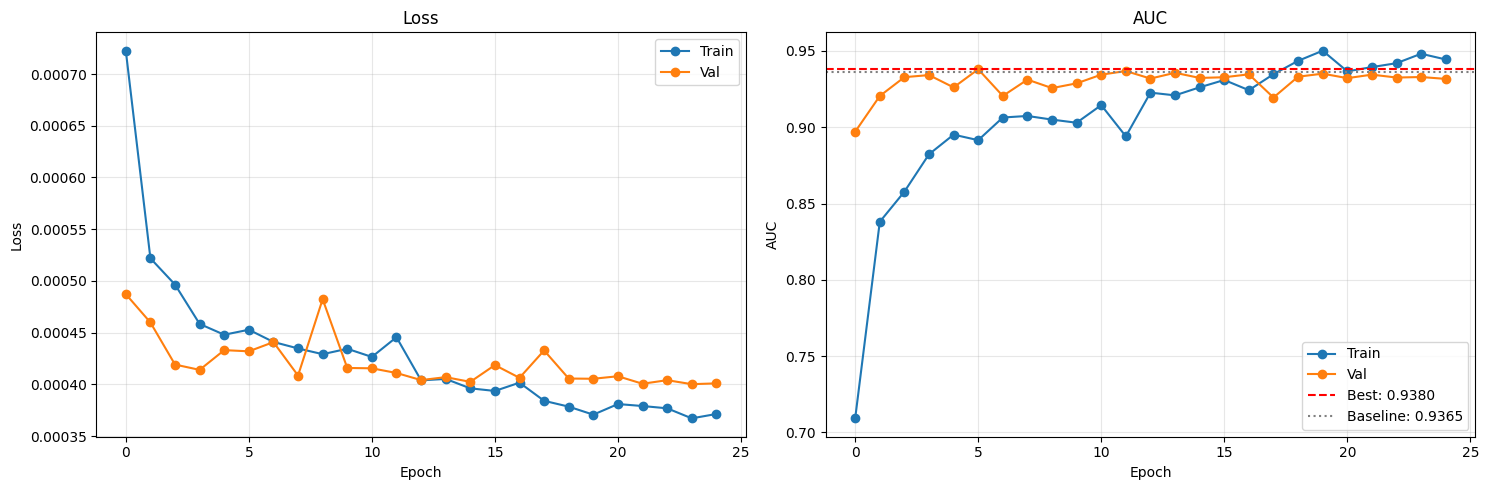

Generating test predictions...


Testing: 100%|████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.10it/s]


SUBMISSION GENERATED
File: submission_resnet34_hybrid.csv
Shape: (100, 2)

Prediction statistics:
count    100.000000
mean       0.085471
std        0.085538
min        0.003471
25%        0.014681
50%        0.044322
75%        0.144540
max        0.269203
Name: target, dtype: float64



In [12]:
# --- Load previous run if available ---
import os

# Set your results directory here to load a previous run, or leave as None to rerun training
load_results_dir = "results/resnet34_hybrid_20251107_182054"  # e.g., Path('results/resnet34_hybrid_20251107_182054')

if load_results_dir is not None and os.path.exists(load_results_dir):
    print(f"Loading previous run from: {load_results_dir}")
    # Load model checkpoint
    checkpoint = torch.load(Path(load_results_dir) / 'best_resnet34_hybrid.pth', map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    best_auc = checkpoint.get('val_auc', None)

    # Load training history
    with open(Path(load_results_dir) / 'training_results.pkl', 'rb') as f:
        training_results = pickle.load(f)
        history = training_results['history']
        total_params = training_results.get('total_params', None)
        trainable_params = training_results.get('trainable_params', None)

    # Load preprocessors (scaler, encoders)
    with open(Path(load_results_dir) / 'preprocessors.pkl', 'rb') as f:
        preprocessors = pickle.load(f)
        scaler = preprocessors['scaler']
        encoders = preprocessors['encoders']

    results_dir = Path(load_results_dir)
else:
    print("No previous run loaded. Will use current training results.")

# ROC curve
checkpoint = torch.load(results_dir / 'best_resnet34_hybrid.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
_, _, val_preds, val_labels = validate(model, val_loader, criterion, device)

fpr, tpr, thresholds = roc_curve(val_labels, val_preds)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {best_auc:.4f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random')
plt.plot(fpr[optimal_idx], tpr[optimal_idx], 'go', markersize=12, 
         label=f'Threshold = {optimal_threshold:.4f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - ResNet34 Hybrid')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(results_dir / 'roc_curve.png', dpi=150)
print(f"✓ ROC curve saved\n")
plt.show()

# Training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history['train_loss'], label='Train', marker='o')
axes[0].plot(history['val_loss'], label='Val', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_auc'], label='Train', marker='o')
axes[1].plot(history['val_auc'], label='Val', marker='o')
axes[1].axhline(y=best_auc, color='r', linestyle='--', label=f'Best: {best_auc:.4f}')
axes[1].axhline(y=0.9365, color='gray', linestyle=':', label='Baseline: 0.9365')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].set_title('AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / 'training_history.png', dpi=150)
print(f"✓ Training plots saved\n")
plt.show()

# Generate test predictions
print("Generating test predictions...")
model.eval()
test_ids = []
test_preds = []

with torch.no_grad():
    for images, metadata, img_ids in tqdm(test_loader, desc="Testing", ncols=100):
        images = images.to(device, non_blocking=True)
        metadata = metadata.to(device, non_blocking=True)
        outputs = model(images, metadata)
        probs = torch.sigmoid(outputs).cpu().numpy()
        test_ids.extend(img_ids)
        test_preds.extend(probs.flatten())

submission = pd.DataFrame({'isic_id': test_ids, 'target': test_preds})
submission.to_csv(results_dir / 'submission_resnet34_hybrid.csv', index=False)

print(f"\n{'='*70}")
print("SUBMISSION GENERATED")
print(f"{'='*70}")
print(f"File: submission_resnet34_hybrid.csv")
print(f"Shape: {submission.shape}")
print(f"\nPrediction statistics:")
print(submission['target'].describe())
print(f"{'='*70}\n")

## 9. Comparison Summary

In [ ]:
print("="*70)
print("MODEL COMPARISON")
print("="*70)
print("\nBaseline (Custom CNN + Metadata):")
print(f"  Val AUC: 0.9365")
print(f"  Parameters: ~27M")
print(f"  Training: From scratch")

print(f"\nResNet34 Hybrid:")
print(f"  Val AUC: {best_auc:.4f}")
print(f"  Parameters: {total_params:,} ({trainable_params:,} trainable)")
print(f"  Training: Transfer learning (ImageNet pretrained)")
print(f"  Improvement: {best_auc - 0.9365:+.4f} ({(best_auc - 0.9365)/0.9365*100:+.1f}%)")

if best_auc is not None and best_auc > 0.95:
    print(f"\n🎉 Excellent! Likely 2nd place on leaderboard!")
elif best_auc is not None and best_auc > 0.94:
    print(f"\n✓ Good improvement! Competing for 2nd-3rd place")
else:
    print(f"\n⚠ Modest improvement. May need more training or ensemble")

print("="*70)